## Google Colab Notebook Code

### 1. Setup Environment and Verify GPU
Installs Ultralytics (YOLOv8), ONNX exporter, and dependencies.

In [1]:
!pip install ultralytics onnx onnxruntime opencv-python-headless matplotlib pillow

import torch
import os
from google.colab import files

print("--- ENVIRONMENT CHECK ---")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU Active: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU not detected. Go to Runtime > Change runtime type > T4 GPU.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 6.7 MB/s eta 0:00:00
--- ENVIRONMENT CHECK ---
PyTorch Version: 2.11.0+cu128
GPU Active: Tesla T4


### 2. Create Dataset Directory Structure
This cell sets up the directory layout and creates dummy images so the entire notebook is runnable out-of-the-box.

In [2]:
import os
import numpy as np
from PIL import Image

# Define root dataset directory
DATASET_DIR = "/content/selfie_helmet_dataset"
CLASSES = ["full_face_helmet", "half_face_helmet", "no_helmet"]

# Create Train and Validation folders
for split in ["train", "val"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(DATASET_DIR, split, cls), exist_ok=True)

# Generate dummy images so you can test training right now
def generate_dummy_images(folder, count=10):
    for cls in CLASSES:
        target_path = os.path.join(folder, cls)
        for i in range(count):
            # Create a simple colored random image (224x224)
            img_data = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
            img = Image.fromarray(img_data)
            img.save(os.path.join(target_path, f"sample_{i}.jpg"))

generate_dummy_images(os.path.join(DATASET_DIR, "train"), count=20)
generate_dummy_images(os.path.join(DATASET_DIR, "val"), count=5)

print(f"Dataset structure ready at: {DATASET_DIR}")
print("Folders created for: full_face_helmet, half_face_helmet, no_helmet")

Dataset structure ready at: /content/selfie_helmet_dataset
Folders created for: full_face_helmet, half_face_helmet, no_helmet


### 3. Train the YOLO Classification Model
Fine-tunes the lightweight YOLOv8 nano classifier (`yolov8n-cls`) on your selfie classes.

In [3]:
from ultralytics import YOLO

# 1. Load pre-trained weights
model = YOLO('yolov8n-cls.pt')

# 2. Train on your selfie dataset
# Change epochs to 30-50 when training on your actual real images
results = model.train(
    data=DATASET_DIR,
    epochs=5,               # Increase for real dataset
    imgsz=224,              # Standard input resolution for classification
    batch=16,
    project='helmet_project',
    name='selfie_classifier',
    exist_ok=True
)

print("\nTraining completed successfully!")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/selfie_helmet_dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, for

### 4. Verify Inference Logic (True / False Output)
Tests the trained model on an image, applies confidence thresholds, and formats the output into a production JSON response.

Loading model weights from: /content/runs/classify/helmet_project/selfie_classifier/weights/best.pt

--- INFERENCE RESULT ---
{'helmet_worn': False, 'detected_class': 'full_face_helmet', 'confidence': 0.4753}


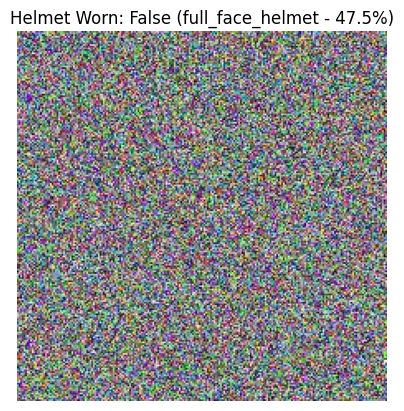

In [6]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Correct path generated by Ultralytics classification trainer
WEIGHTS_PATH = "/content/runs/classify/helmet_project/selfie_classifier/weights/best.pt"

# Fallback to last.pt if best.pt isn't found
if not os.path.exists(WEIGHTS_PATH):
    WEIGHTS_PATH = "/content/runs/classify/helmet_project/selfie_classifier/weights/last.pt"

print(f"Loading model weights from: {WEIGHTS_PATH}")
trained_model = YOLO(WEIGHTS_PATH)

def verify_selfie(image_path, confidence_threshold=0.65):
    # Run classification
    results = trained_model(image_path, verbose=False)

    # Get top prediction class ID and confidence score
    top1_index = results[0].probs.top1
    predicted_class = results[0].names[top1_index]
    confidence = float(results[0].probs.top1conf)

    # Business logic: True if full or half helmet with sufficient confidence
    helmet_worn = (predicted_class in ["full_face_helmet", "half_face_helmet"]) and (confidence >= confidence_threshold)

    return {
        "helmet_worn": helmet_worn,
        "detected_class": predicted_class,
        "confidence": round(confidence, 4)
    }

# Test on a validation sample
test_image_path = "/content/selfie_helmet_dataset/val/full_face_helmet/sample_0.jpg"

response = verify_selfie(test_image_path)

print("\n--- INFERENCE RESULT ---")
print(response)

# Display image
img = cv2.imread(test_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.title(f"Helmet Worn: {response['helmet_worn']} ({response['detected_class']} - {response['confidence']*100:.1f}%)")
plt.imshow(img)
plt.axis("off")
plt.show()

### 5. Export Model for Server Deployment
Exports the trained PyTorch model (`best.pt`) to ONNX format (`best.onnx`) and triggers a file download to your computer.

In [7]:
import os
from ultralytics import YOLO
from google.colab import files

WEIGHTS_PATH = "/content/runs/classify/helmet_project/selfie_classifier/weights/best.pt"

if not os.path.exists(WEIGHTS_PATH):
    WEIGHTS_PATH = "/content/runs/classify/helmet_project/selfie_classifier/weights/last.pt"

export_model = YOLO(WEIGHTS_PATH)

# 1. Export to ONNX format for lightweight server inference
onnx_file_path = export_model.export(format="onnx")
print(f"ONNX Model saved to: {onnx_file_path}")

# 2. Trigger browser downloads for both files
print("Downloading weight files to your computer...")
files.download(WEIGHTS_PATH)
files.download(onnx_file_path)

Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 0.4 GFLOPs

PyTorch: starting from '/content/runs/classify/helmet_project/selfie_classifier/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 3) (2.8 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 10 packages in 243ms
Prepared 2 packages in 41ms
Installed 2 packages in 6ms
 + colorama==0.4.6
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 1.3s, save

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Production Backend Server Setup (No Retraining Needed)

Once you download `best.pt` or `best.onnx` from Colab, you **never need Colab or training code again**. Place the weight file into your server project directory alongside this deployment script.

### Backend Implementation (`server.py`)

Here is a ready-to-use production server script powered by **FastAPI** that loads your exported model once into memory and handles incoming photo requests instantly:

In [ ]:
from fastapi import FastAPI, UploadFile, File, HTTPException
from ultralytics import YOLO
import cv2
import numpy as np

app = FastAPI(title="Selfie Helmet Verification API")

# Load model weights into RAM once when server starts
# Replace "best.pt" with your actual exported file path
MODEL_PATH = "best.pt"
CONFIDENCE_THRESHOLD = 0.70

try:
    model = YOLO(MODEL_PATH)
    print("Selfie Helmet Classifier loaded successfully into server memory.")
except Exception as e:
    raise RuntimeError(f"Failed to load model file: {e}")

@app.post("/verify-helmet")
async def verify_helmet(file: UploadFile = File(...)):
    # Validate file format
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File uploaded must be an image.")

    # 1. Convert incoming file stream to OpenCV image array
    contents = await file.read()
    np_array = np.frombuffer(contents, np.uint8)
    img = cv2.imdecode(np_array, cv2.IMREAD_COLOR)

    if img is None:
        raise HTTPException(status_code=400, detail="Invalid or corrupt image data.")

    # 2. Perform Inference
    results = model(img, verbose=False)

    top1_index = results[0].probs.top1
    predicted_class = results[0].names[top1_index]
    confidence = float(results[0].probs.top1conf)

    # 3. Decision Logic
    is_helmet_valid = (
        predicted_class in ["full_face_helmet", "half_face_helmet"]
    ) and (confidence >= CONFIDENCE_THRESHOLD)

    # 4. Return API Response
    return {
        "status": "success",
        "helmet_worn": is_helmet_valid,
        "details": {
            "predicted_class": predicted_class,
            "confidence": round(confidence, 4),
            "threshold_applied": CONFIDENCE_THRESHOLD
        }
    }

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)

## How to Run the Server

1. Install dependencies on your server:
```bash
pip install fastapi uvicorn ultralytics opencv-python-headless

```


2. Run the server:
```bash
python server.py

```


3. Send a `POST` request to `http://<your-server-ip>:8000/verify-helmet` with a selfie file in the `file` parameter. The server will respond with:
```json
{
  "status": "success",
  "helmet_worn": true,
  "details": {
    "predicted_class": "full_face_helmet",
    "confidence": 0.9421,
    "threshold_applied": 0.70
  }
}
```